<a href="https://colab.research.google.com/github/IvanMalkS/IS/blob/master/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №5: Прототип оценки стоимости домов

**Задача:** Регрессия — прогнозирование медианной стоимости домов в Калифорнии.  
**Датасет:** California Housing (scikit-learn)  
**Модели:** LinearRegression, DecisionTreeRegressor

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
import warnings; warnings.filterwarnings('ignore')

## 1. Исследование данных и целевой переменной

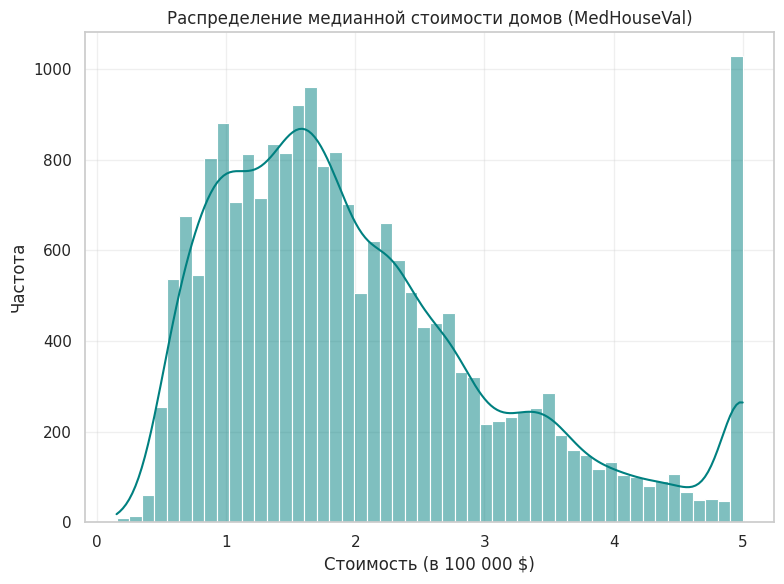

Выбраны признаки для анализа: ['MedInc', 'AveRooms']
 - MedInc: Медианный доход в районе
 - AveRooms: Среднее количество комнат


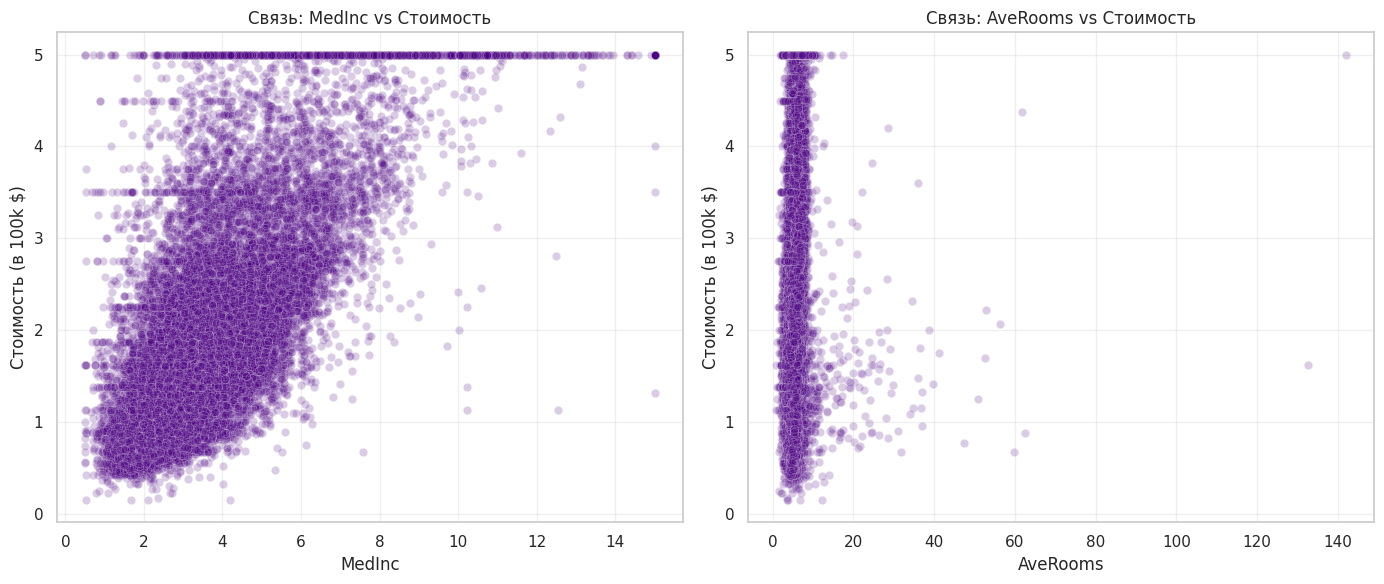

In [30]:
california = fetch_california_housing()
X_full = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MedHouseVal')

plt.figure(figsize=(8, 6))
sns.histplot(y, bins=50, kde=True, color='teal')
plt.title('Распределение медианной стоимости домов (MedHouseVal)')
plt.xlabel('Стоимость (в 100 000 $)')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('target_histogram.png')
plt.show()
selected_features = ['MedInc', 'AveRooms']
print(f"Выбраны признаки для анализа: {selected_features}")
print(" - MedInc: Медианный доход в районе")
print(" - AveRooms: Среднее количество комнат")

X = X_full[selected_features]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, feature in enumerate(selected_features):
    sns.scatterplot(x=X[feature], y=y, alpha=0.2, ax=axes[i], color='indigo')
    axes[i].set_title(f'Связь: {feature} vs Стоимость')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Стоимость (в 100k $)')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('features_vs_target.png')
plt.show()

### Очистка выбросов
Убираем дома со стоимостью 5.0 (это искусственная "заглушка" в данных для домов >$500k) и дома с аномальным количеством комнат (например, 130 комнат)

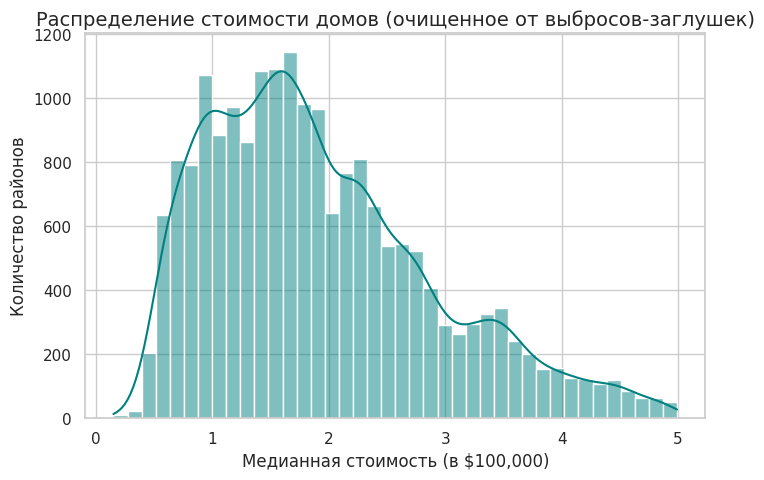

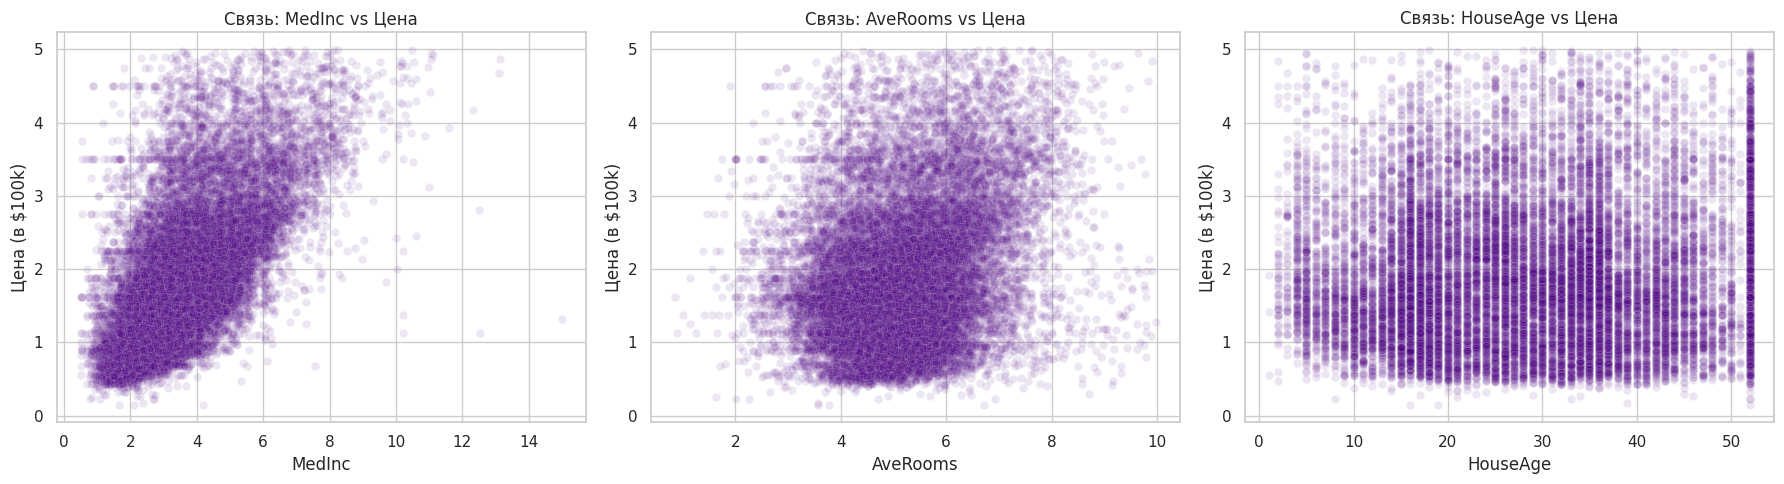

In [31]:
california = fetch_california_housing(as_frame=True)
df = california.frame

df_clean = df[(df['MedHouseVal'] < 5.0) & (df['AveRooms'] < 10)]

X = df_clean.drop('MedHouseVal', axis=1)
y = df_clean['MedHouseVal']

plt.figure(figsize=(8, 5))
sns.histplot(y, bins=40, kde=True, color='teal')
plt.title('Распределение стоимости домов (очищенное от выбросов-заглушек)', fontsize=14)
plt.xlabel('Медианная стоимость (в $100,000)')
plt.ylabel('Количество районов')
plt.show()

selected_features = ['MedInc', 'AveRooms', 'HouseAge']
X_selected = X[selected_features]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(selected_features):
    sns.scatterplot(x=X_selected[feature], y=y, alpha=0.1, color='indigo', ax=axes[i])
    axes[i].set_title(f'Связь: {feature} vs Цена')
    axes[i].set_ylabel('Цена (в $100k)')
plt.tight_layout()
plt.show()

## 2. Обучение и оценка линейной модели

In [32]:

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.25, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Метрики Линейной Регрессии:")
print(f"MAE: {mae_lr:.4f} (Ошибка в среднем на ${mae_lr * 100000:,.0f})")
print(f"MSE: {mse_lr:.4f}")
print(f"R2:  {r2_lr:.4f} (Модель объясняет {r2_lr*100:.1f}% дисперсии)")
print("-" * 50)

print("БИЗНЕС-ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ:")
print(f"Базовая стоимость (Intercept): ${lr_model.intercept_ * 100000:,.0f}")

coefs = dict(zip(selected_features, lr_model.coef_))
print(f"1. Доход (MedInc): При росте медианного дохода на $10,000, стоимость дома растет на ${coefs['MedInc'] * 100000:,.0f}.")
print(f"2. Комнаты (AveRooms): При добавлении 1 комнаты, стоимость изменяется на ${coefs['AveRooms'] * 100000:,.0f}.")
print(f"3. Возраст (HouseAge): Каждый год старения дома меняет цену на ${coefs['HouseAge'] * 100000:,.0f}.")


Метрики Линейной Регрессии:
MAE: 0.5228 (Ошибка в среднем на $52,283)
MSE: 0.4728
R2:  0.4972 (Модель объясняет 49.7% дисперсии)
--------------------------------------------------
БИЗНЕС-ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ:
Базовая стоимость (Intercept): $68,348
1. Доход (MedInc): При росте медианного дохода на $10,000, стоимость дома растет на $51,549.
2. Комнаты (AveRooms): При добавлении 1 комнаты, стоимость изменяется на $-19,531.
3. Возраст (HouseAge): Каждый год старения дома меняет цену на $1,289.


## 3. Сравнение с нелинейной моделью

In [39]:
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("СРАВНЕНИЕ МОДЕЛЕЙ:")
data_comp = {
    'Модель': ['Linear Regression', 'Decision Tree (depth=3)'],
    'MAE (ошибка в $)': [f"${mae_lr * 100000:,.0f}", f"${mae_dt * 100000:,.0f}"],
    'R2 Score': [round(r2_lr, 4), round(r2_dt, 4)]
}
comp_df = pd.DataFrame(data_comp)
display(comp_df)

СРАВНЕНИЕ МОДЕЛЕЙ:


,Модель,MAE (ошибка в $),R2 Score
0,Linear Regression,"$52,283",0.4972
1,Decision Tree (depth=3),"$55,296",0.4457


## Итоговое сравнение моделей


Для финального графика выбрана модель: LinearRegression


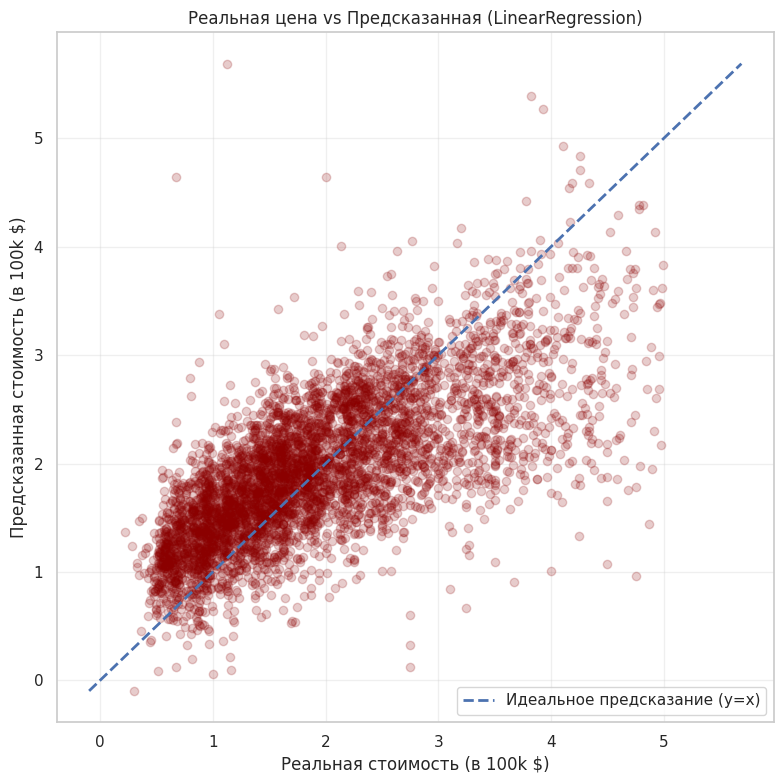

In [34]:
best_model_name = "LinearRegression" if r2_lr > r2_dt else "DecisionTreeRegressor"
best_preds = y_pred_lr if best_model_name == "LinearRegression" else y_pred_dt
print(f"\nДля финального графика выбрана модель: {best_model_name}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.2, color='darkred')
min_val = min(y.min(), best_preds.min())
max_val = max(y.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'b--', lw=2, label='Идеальное предсказание (y=x)')
plt.title(f'Реальная цена vs Предсказанная ({best_model_name})')
plt.xlabel('Реальная стоимость (в 100k $)')
plt.ylabel('Предсказанная стоимость (в 100k $)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('real_vs_pred_scatter.png')
plt.show()

## Результат

*   **Главный фактор:** Медианный доход населения (`MedInc`) является ключевым индикатором. Рост дохода на 10,000 увеличивает цену дома примерно на 51,500.
*   **Парадокс комнат:** Среднее количество комнат (`AveRooms`) имеет отрицательный коэффициент. Это объясняется тем, что высокая плотность застройки (престижные квартиры в центрах городов с малым числом комнат) ценится выше, чем просторные дома в удаленных или менее развитых районах.
*   **Точность:** Коэффициент детерминации $R^2 \approx 0.50$ говорит о том, что выбранные 3 признака описывают ровно половину факторов, влияющих на цену.
*   **Рекомендация для агентства:** Прототип пригоден для быстрой черновой оценки. Для повышения точности (до уровня $R^2 > 0.7$) необходимо внедрить географические данные (долготу и широту), так как близость к океану и конкретный город (Сан-Франциско vs Фресно) критически влияют на стоимость.